In [143]:
import ta
import sklearn
import pandas as pd
import numpy as np
import tensorflow
from tensorflow import keras
from keras import layers
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib import cycler

In [144]:
plt.style.use('seaborn-v0_8-darkgrid')

In [145]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

yfinance  : 0.2.65
matplotlib: 3.9.2
numpy     : 1.26.4
ta        : 0.11.0
keras     : 3.10.0
sklearn   : 1.5.1
pandas    : 2.2.2
tensorflow: 2.19.0



In [146]:
def extrai_dados(ticker):
    dados = yf.download(ticker, start = '2013-01-01')

    if isinstance(dados.columns, pd.MultiIndex):
        dados.columns = [col[0].lower() + "_" + col[1].lower() for col in dados.columns]
    else:
        dados.columns = [col.lower() for col in dados.columns]

    dados.index.name = 'date'

    return dados

In [147]:
def func_engenharia_atributos(df):


    df_copy = df.copy()

    df_copy["retorno_mstr"] = df_copy["close_mstr"].pct_change(1)

    df_copy["op"] = df_copy["open_mstr"].shift(1)
    df_copy["hi"] = df_copy["high_mstr"].shift(1)
    df_copy["lo"] = df_copy["low_mstr"].shift(1)
    df_copy["clo"] = df_copy["close_mstr"].shift(1)

    df_copy["vol"] = df_copy["volume_mstr"].shift(1)

    df_copy["SMA 15"] = df_copy[["close_mstr"]].rolling(15).mean().shift(1)
    df_copy["SMA 60"] = df_copy[["close_mstr"]].rolling(60).mean().shift(1)

    df_copy["MSD 15"] = df_copy["retorno_mstr"].rolling(15).std().shift(1)
    df_copy["MSD 60"] = df_copy["retorno_mstr"].rolling(60).std().shift(1)

    vwap = ta.volume.VolumeWeightedAveragePrice(high = df['high_mstr'],
                                                low = df['low_mstr'],
                                                close = df['close_mstr'],
                                                volume = df['volume_mstr'],
                                                window = 5)
    
    df_copy["VWAP"] = vwap.vwap.shift(1)

    RSI = ta.momentum.RSIIndicator(df_copy["close_mstr"], window = 5, fillna = False)
    
    df_copy["RSI"] = RSI.rsi().shift(1)

    return df_copy.dropna()

In [148]:
df = extrai_dados('MSTR')

C:\Users\conta\AppData\Local\Temp\ipykernel_12000\3575705638.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ticker, start = '2013-01-01')
[*********************100%***********************]  1 of 1 completed


In [149]:
df = func_engenharia_atributos(df)

In [150]:
df.head()

,close_mstr,high_mstr,low_mstr,open_mstr,volume_mstr,retorno_mstr,op,hi,lo,clo,vol,SMA 15,SMA 60,MSD 15,MSD 60,VWAP,RSI
date,,,,,,,,,,,,,,,,,
2013-04-02,10.253,10.430,10.157,10.320,830000,-0.004853,10.130,10.329,10.020,10.303,1209000.0,10.731400,10.157950,0.015370,0.023398,10.185200,41.179936
2013-04-03,10.144,10.395,10.061,10.395,742000,-0.010631,10.320,10.430,10.157,10.253,830000.0,10.663667,10.174750,0.015272,0.023002,10.192879,37.928719
2013-04-04,10.103,10.213,10.027,10.127,586000,-0.004042,10.395,10.395,10.061,10.144,742000.0,10.588667,10.188833,0.015212,0.023053,10.189737,31.213394
2013-04-05,10.054,10.180,9.912,9.961,847000,-0.004850,10.127,10.213,10.027,10.103,586000.0,10.510200,10.201100,0.015081,0.023053,10.189374,28.814656
2013-04-08,10.145,10.209,9.991,10.065,870000,0.009051,9.961,10.180,9.912,10.054,847000.0,10.427600,10.214583,0.014922,0.022990,10.178400,25.847277


<Axes: xlabel='date'>

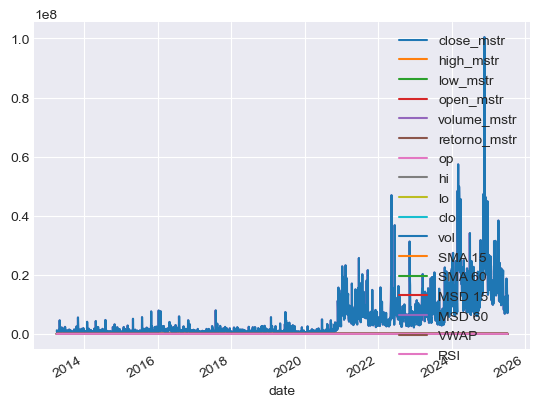

In [151]:
df.plot()

In [152]:
split = int(0.85*len(df))
split_val = int(0.95*len(df))

In [153]:
df.columns

Index(['close_mstr', 'high_mstr', 'low_mstr', 'open_mstr', 'volume_mstr',
       'retorno_mstr', 'op', 'hi', 'lo', 'clo', 'vol', 'SMA 15', 'SMA 60',
       'MSD 15', 'MSD 60', 'VWAP', 'RSI'],
      dtype='object')

In [154]:
x_treino = df[[ 'op', 'hi', 'lo', 'clo', 'vol', 'SMA 15', 'SMA 60','MSD 15', 'MSD 60', 'VWAP', 'RSI']].iloc[:split, :]
y_treino = df[['retorno_mstr']].iloc[:split, :]

In [155]:
x_valid = df[[ 'op', 'hi', 'lo', 'clo', 'vol', 'SMA 15', 'SMA 60','MSD 15', 'MSD 60', 'VWAP', 'RSI']].iloc[split:split_val, :]
y_valid = df[['retorno_mstr']].iloc[split:split_val, :]

In [156]:
x_teste = df[[ 'op', 'hi', 'lo', 'clo', 'vol', 'SMA 15', 'SMA 60','MSD 15', 'MSD 60', 'VWAP', 'RSI']].iloc[split_val:, :]
y_teste = df[['retorno_mstr']].iloc[split_val:, :]

In [157]:
sc = StandardScaler()

In [158]:
x_treino_sc = sc.fit_transform(x_treino)

In [159]:
x_valid_sc = sc.transform(x_valid)

In [160]:
x_teste_sc = sc.transform(x_teste)

In [161]:
def ajusta_formato_dados(X_s, y_s, lag):

    if len(X_s) != len(y_s):
        print("Warnings")

    X_train = []
    
    for variable in range(0, X_s.shape[1]):
        
        X = []
        
        for i in range(lag, X_s.shape[0]):
            X.append(X_s[i-lag:i, variable])
        
        X_train.append(X)
    
    X_train, np.array(X_train)
    
    X_train = np.swapaxes(np.swapaxes(X_train, 0, 1), 1, 2)

    y_train = []
    
    for i in range(lag, y_s.shape[0]):
        y_train.append(y_s[i, :].reshape(-1,1).transpose())
    
    y_train = np.concatenate(y_train, axis = 0)
    
    return X_train, y_train

In [162]:
lag = 15

In [163]:
x_treino_final, y_treino_final = ajusta_formato_dados(x_treino_sc, y_treino.values, lag)

In [164]:
x_valid_final, y_valid_final = ajusta_formato_dados(x_valid_sc, y_valid.values, lag)

In [165]:
x_teste_final, y_teste_final = ajusta_formato_dados(x_teste_sc, y_teste.values, lag)

In [166]:
print(f'Shape dos dados de treino: {x_treino_final.shape}')
print(f'Shape dos dados de validação: {x_valid_final.shape}')
print(f'Shape dos dados de teste: {x_teste_final.shape}')

Shape dos dados de treino: (2610, 15, 11)
Shape dos dados de validação: (294, 15, 11)
Shape dos dados de teste: (140, 15, 11)


In [167]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout = 0):
    
    x = layers.LayerNormalization(epsilon = 1e-6)(inputs)
    
    x = layers.MultiHeadAttention(key_dim = head_size, num_heads = num_heads, dropout = dropout)(x, x, x)
    
    x = layers.Dropout(dropout)(x)
    
    res = x + inputs
    
    x = layers.LayerNormalization(epsilon = 1e-6)(res)
    x = layers.Conv1D(filters = ff_dim, kernel_size = 1, activation = "relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters = inputs.shape[-1], kernel_size = 1)(x)
    
    return x + res

In [168]:
def cria_modelo(input_shape, 
                head_size, 
                num_heads, 
                ff_dim, 
                num_transformer_blocks, 
                mlp_units, 
                dropout = 0, 
                mlp_dropout = 0,
                l1_reg = 0.0,
                l2_reg = 0.0):
    
    inputs = keras.Input(shape = input_shape)
    
    x = inputs
    
    x = layers.LSTM(10, return_sequences = True)(x)
    
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    x = layers.GRU(100, return_sequences = False)(x)
    
    x = layers.Dropout(mlp_dropout)(x)
    
    x = layers.Dense(mlp_units, activation = "relu", kernel_regularizer=keras.regularizers.l1_l2(l1=l1_reg, l2=l2_reg))(x)
    
    outputs = layers.Dense(1)(x)
    
    return keras.Model(inputs, outputs)

In [169]:
input_shape = x_treino_final.shape[1:]

modelo = cria_modelo(input_shape,
                     head_size = 16,
                     num_heads = 2,
                     ff_dim = 8,
                     num_transformer_blocks = 2,
                     mlp_units = 250,
                     dropout = 0.2,
                     mlp_dropout = 0.3,
                     l1_reg = 0.001,
                     l2_reg = 0.001)

modelo.compile(loss = 'mean_squared_error', optimizer = keras.optimizers.Adam())

callbacks = [keras.callbacks.EarlyStopping(patience = 10, restore_best_weights = True)]

In [170]:
modelo.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 15, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 15, 10)    │        880 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 10)    │         20 │ lstm_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 10)    │      1,386 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 15, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 15, 10)    │          0 │ dropout_5[0][0],  │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 10)    │         20 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 15, 8)     │         88 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 15, 8)     │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 15, 10)    │         90 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 15, 10)    │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 10)    │         20 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 10)    │      1,386 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 15, 10)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 15, 10)    │          0 │ dropout_8[0][0],  │
│                     │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 10)    │         20 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 15, 8)     │         88 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 15, 8)     │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 15, 10)    │         90 │ dropout_9[0][0] 

 Total params: 63,189 (246.83 KB)

 Trainable params: 63,189 (246.83 KB)

 Non-trainable params: 0 (0.00 B)

In [171]:
callbacks = [keras.callbacks.EarlyStopping(patience = 5, restore_best_weights = True)]

In [172]:
%%time

modelo.fit(x_treino_final,
            y_treino_final,
            validation_data = (x_valid_final, y_valid_final),
            epochs = 30,
            batch_size = 128,
            callbacks = callbacks)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 1.6989 - val_loss: 1.3512
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1.2450 - val_loss: 0.9422
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.8520 - val_loss: 0.6062
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.5346 - val_loss: 0.3484
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.2963 - val_loss: 0.1683
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1348 - val_loss: 0.0636
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0476 - val_loss: 0.0240
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0169 - val_loss: 0.0115
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0075 - val_loss: 0.0081
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0051 - val_loss: 0.0072
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0044 - val_loss: 0.0070
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.

<Axes: >

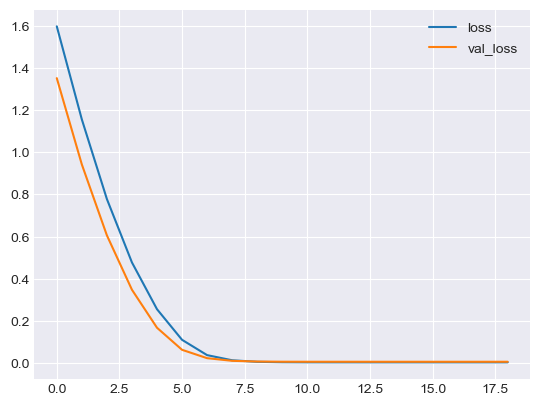

In [173]:
pd.DataFrame(modelo.history.history).plot()

In [174]:
pred = modelo.predict(x_teste_final)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step


In [175]:
score = np.sqrt(metrics.mean_squared_error(pred, y_teste_final))

In [177]:
print("Score (RMSE): {}".format(score))

Score (RMSE): 0.05643484954560959


In [178]:
y_pred_treino = np.concatenate((np.zeros([lag,1]), modelo.predict(x_treino_final)), axis = 0)
y_pred_valid = np.concatenate((np.zeros([lag,1]), modelo.predict(x_valid_final)), axis = 0)
y_pred_teste = np.concatenate((np.zeros([lag,1]), modelo.predict(x_teste_final)), axis = 0)

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [179]:
df["prediction"] = np.concatenate((y_pred_treino, y_pred_valid, y_pred_teste), axis = 0)

In [180]:
df.tail()

,close_mstr,high_mstr,low_mstr,open_mstr,volume_mstr,retorno_mstr,op,hi,lo,clo,vol,SMA 15,SMA 60,MSD 15,MSD 60,VWAP,RSI,prediction
date,,,,,,,,,,,,,,,,,,
2025-07-07,395.670013,405.640015,395.200012,402.640015,8848200,-0.020595,400.869995,414.600006,400.399994,403.989990,10013900.0,383.052000,371.683500,0.035228,0.048934,392.654131,63.124260,0.002961
2025-07-08,396.940002,402.200012,393.209991,399.690002,7022700,0.003210,402.640015,405.640015,395.200012,395.670013,8848200.0,384.112667,374.312167,0.035303,0.046472,394.639528,54.489785,0.002954
2025-07-09,415.410004,416.339996,395.950012,401.600006,13065400,0.046531,399.690002,402.200012,393.209991,396.940002,7022700.0,385.050667,375.980168,0.035278,0.034392,394.061389,55.647354,0.002949
2025-07-10,421.739990,422.399994,411.200012,412.570007,13038100,0.015238,401.600006,416.339996,395.950012,415.410004,13065400.0,387.261334,378.364668,0.036978,0.032793,401.469111,69.671271,0.002948
2025-07-11,429.649994,438.839996,423.500000,430.540009,11331785,0.018756,412.570007,422.399994,411.200012,421.739990,13038100.0,390.365334,380.394001,0.036390,0.030411,407.623514,73.289365,0.002942


In [182]:
df["strategy"] = df["retorno_mstr"] * np.sign(df["prediction"].shift(1))

In [183]:
df.tail()

,close_mstr,high_mstr,low_mstr,open_mstr,volume_mstr,retorno_mstr,op,hi,lo,clo,vol,SMA 15,SMA 60,MSD 15,MSD 60,VWAP,RSI,prediction,strategy
date,,,,,,,,,,,,,,,,,,,
2025-07-07,395.670013,405.640015,395.200012,402.640015,8848200,-0.020595,400.869995,414.600006,400.399994,403.989990,10013900.0,383.052000,371.683500,0.035228,0.048934,392.654131,63.124260,0.002961,-0.020595
2025-07-08,396.940002,402.200012,393.209991,399.690002,7022700,0.003210,402.640015,405.640015,395.200012,395.670013,8848200.0,384.112667,374.312167,0.035303,0.046472,394.639528,54.489785,0.002954,0.003210
2025-07-09,415.410004,416.339996,395.950012,401.600006,13065400,0.046531,399.690002,402.200012,393.209991,396.940002,7022700.0,385.050667,375.980168,0.035278,0.034392,394.061389,55.647354,0.002949,0.046531
2025-07-10,421.739990,422.399994,411.200012,412.570007,13038100,0.015238,401.600006,416.339996,395.950012,415.410004,13065400.0,387.261334,378.364668,0.036978,0.032793,401.469111,69.671271,0.002948,0.015238
2025-07-11,429.649994,438.839996,423.500000,430.540009,11331785,0.018756,412.570007,422.399994,411.200012,421.739990,13038100.0,390.365334,380.394001,0.036390,0.030411,407.623514,73.289365,0.002942,0.018756


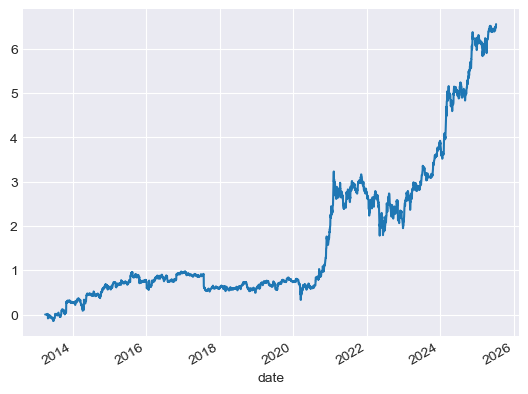

In [184]:
df["strategy"].iloc[:].cumsum().plot()
plt.show()